# STAT 207 Project 03 - Linear and Logistic Regression for Video Games

Tara Vittal & Jaclyn Rizzo

<hr>

### Contribution Report

Should we grade your submission?  If not, write the netID of the submission to be graded.  (Note: We will only grade one assignment per group, and we'll pick the first one that says we should grade that submission.  We will assign the same grade to all team members.)

*For example*, you might respond: **grade this submission** or **my submission is under netID jdeeke**

grade this submission

If you said **my submission is under netID** above, we will not grade any of your project submission.

If you said **grade this submission** above, who worked with you on this project?  Write both their **names** and **netIDs**.  

jcrizzo2 Jacyln Rizzo 

You should list the contribution of each team member to the report.

*For example:*

*John Smith (smith92) & Jane Doe (doe105) worked together on all parts of this project*

OR

<i>1. John Smith (smith92) completed parts 1 - 3</i>

<i>2. Jane Doe (doe105) completed parts 4 - 5</i>

<i>We both reviewed the full document before submission.</i>

We both worked on all parts of the project together

Group Work Reflection

Reflecting on your experience working as a group, how do you think the project went?  What were the most effective things your group did to work together?  What were the least effective things your group did to work together?  What have you learned about group work from the last project?  What might you change about your group's process or dynamics for the next project?  Did you face any substantial challenges in working together?  If so, please explain any challenges that you had.

*Note*: this can be completed individually or as a group, and each person can submit their own reflection to their own repository/submission or completely within the group submission.  If you would like your TA to read your individual reflection and yours is not the submission to be graded, be sure to email your TA.

My partner and I worked really well together on this project, and we helped each other a lot, especially when it came to figuring out the code and fixing errors. We communicated clearly about who was doing what, which made it easy for us to divide the work and stay organized. Most of the written questions we worked on independently, but we always checked in to make sure our answers matched and made sense. The only thing we could have improved was starting a little earlier so we had more time to review our work together at the end. Overall, I learned that group work goes smoothly when both people stay engaged, share the workload, and support each other when things get confusing.

## 1. Introduction

This dataset details information about thousands of games, all released betwee 2004-2010. Our dataset shows different Console types, titles of the games released on those consoles, and corresponsnding attributes/variables about the games. Some of the variables include the genre of game, amount of sales (in millions), and release year. There are 166 columns of attributes for each of the games, and there are 5 different console types. 

In [17]:
#Imports here
import pandas as pd                    # imports pandas and calls the imported version 'pd'
import matplotlib.pyplot as plt        # imports the package and calls it 'plt'
import seaborn as sns                  # imports the seaborn package with the imported name 'sns'
sns.set()  
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf

In [18]:
df = pd.read_csv("video_games.csv", encoding="unicode_escape")
df.head()

,Console,Title,US Sales (millions),Block4,Block2,Block1,Block0.5,YearReleased,2004,2005,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
0,Nintendo DS,Super Mario 64 DS,4.69,1,1,1,1,2004,1,0,...,0,0,0,0,0,1,0,0,0,1
1,Sony PSP,Lumines: Puzzle Fusion,0.56,0,0,0,1,2004,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Nintendo DS,WarioWare Touched!,0.54,0,0,0,1,2004,1,0,...,0,0,0,0,0,1,1,1,1,1
3,Sony PSP,Hot Shots Golf: Open Tee,0.49,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,0,1
4,Nintendo DS,Spider-Man 2,0.45,0,0,0,0,2004,1,0,...,0,0,0,0,0,1,0,1,0,1


Linear Regression: What is the relationship between YearReleased and US Sales (millions) after controlling for Console, FirstPerson, and ThirdPerson, both in the sample and in the underlying population? And how does the new model perform on the new data?

Logistic Regression: How do YearReleased, Console, and FirstPerson relate to the log-odds of a video game achieving high U.S. sales (Block4) in the sample training data? How does a classifier built on this model perform on the new data?

The response variable for the linear regression test is the US Sales (millions). The response variable for the logistic regression test is Block4. 

Understanding the answers to these research questions would help anyone in the video game industry make smarter decisions about when and how to release new titles. If developers know how factors like release year, console, or gameplay perspective influence sales, they can better predict whether a new game is likely to perform well before investing huge amounts of money into development and marketing. A publisher might use the linear regression results to estimate expected sales for a planned game, while the logistic regression model could help identify which upcoming projects have true blockbuster potential. These insights could guide decisions about budgeting, console partnerships, and genre focus. Even outside the industry, analysts and researchers could use these findings to understand broader trends in gaming popularity and market behavior.

## 2. Linear Regression Analytical Tasks

What is the relationship between YearReleased and US Sales (millions) after controlling for Console, FirstPerson, and ThirdPerson, both in the sample and in the underlying population? And how does the new model perform on the new data?


In [19]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, random_state=30)

In [20]:
model = smf.ols('Q("US Sales (millions)") ~ YearReleased + Console + FirstPerson + ThirdPerson', data=train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                               
====================================================================================
Dep. Variable:     Q("US Sales (millions)")   R-squared:                       0.018
Model:                                  OLS   Adj. R-squared:                  0.012
Method:                       Least Squares   F-statistic:                     3.147
Date:                      Thu, 20 Nov 2025   Prob (F-statistic):            0.00266
Time:                              11:12:30   Log-Likelihood:                -1869.1
No. Observations:                      1239   AIC:                             3754.
Df Residuals:                          1231   BIC:                             3795.
Df Model:                                 7                                         
Covariance Type:                  nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   89.8697     51.755      1.736      0.083     -11.667     191.407
Console[T.Nintendo Wii]      0.1598      0.106      1.503      0.133      -0.049       0.368
Console[T.PlayStation 3]    -0.0196      0.107     -0.183      0.855      -0.230       0.191
Console[T.Sony PSP]         -0.2958      0.101     -2.932      0.003      -0.494      -0.098
Console[T.X360]              0.0337      0.094      0.359      0.720      -0.150       0.218
YearReleased                -0.0446      0.026     -1.728      0.084      -0.095       0.006
FirstPerson                  0.1500      0.076      1.961      0.050   -3.69e-05       0.300
ThirdPerson                  0.0542      0.077      0.701      0.483      -0.097       0.206
==============================================================================
Omnibus:                     1636.485   Durbin-Watson:                   2.020
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           243197.448
Skew:                           7.236   Prob(JB):                         0.00
Kurtosis:                      70.093   Cond. No.                     3.33e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.33e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Predicted US Sales (millions) = 89.8697 − 0.00446(YearReleased) + 0.1500(FirstPerson) + 0.0542(ThirdPerson) +  0.1598(Console[T.Nintendo Wii])

The slope for YearReleased is –0.00446, meaning that after controlling for Console, FirstPerson, and ThirdPerson, each additional release year is associated with a decrease of about 0.00446 million U.S. sales on average. This equals roughly 4,460 fewer units sold per year.

In [21]:
coef = model.params["YearReleased"]
se = model.bse["YearReleased"]

lower = coef - 1.96 * se
upper = coef + 1.96 * se

(lower, upper)

(np.float64(-0.09510718801011656), np.float64(0.005989293540890089))

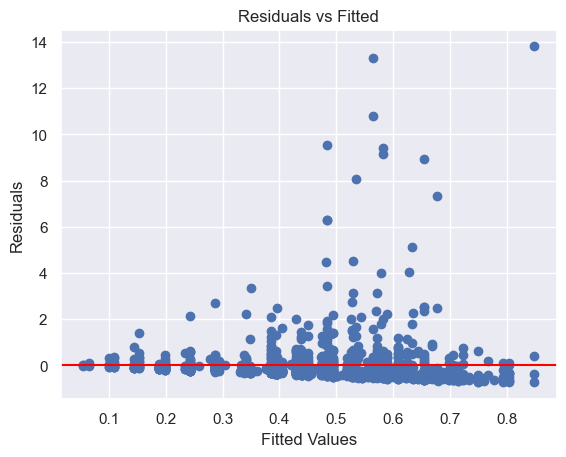

In [22]:
fitted = model.fittedvalues
resid = model.resid
plt.scatter(fitted, resid)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

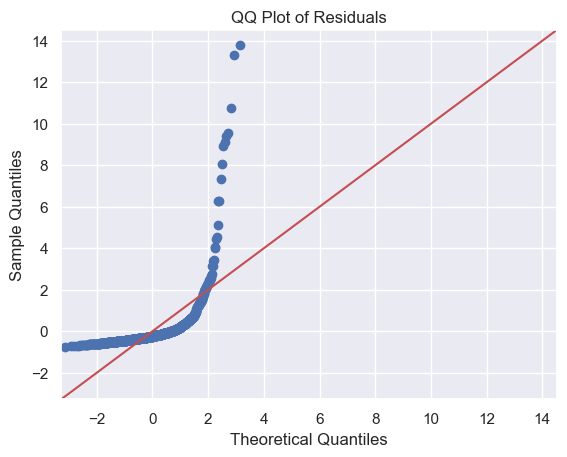

In [23]:
import statsmodels.api as sm
sm.qqplot(resid, line='45')
plt.title("QQ Plot of Residuals")
plt.show()

Both plots show that several important linear regression assumptions are not met. The Residuals vs. Fitted plot shows a clear pattern rather than random scatter, which suggests issues with linearity and constant variance. The Q–Q plot also shows large deviations from the straight reference line, indicating that the residuals are not normally distributed. These problems suggest that the model does not fully capture the structure of the data. Because of this, the slope interpretation and confidence interval should be viewed with caution.

## 3. Logistic Regression Analytical Tasks

How do YearReleased, Console, and FirstPerson relate to the log-odds of a video game achieving high U.S. sales (Block4) in the sample training data? How does a classifier built on this model perform on the new data?

In [24]:
threshold = train['US Sales (millions)'].median()
train['Success'] = (train['US Sales (millions)'] > threshold).astype(int)
logit_model = smf.logit('Success ~ YearReleased + Console + FirstPerson + ThirdPerson', data = train).fit()
logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.669583
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                Success   No. Observations:                 1239
Model:                          Logit   Df Residuals:                     1231
Method:                           MLE   Df Model:                            7
Date:                Thu, 20 Nov 2025   Pseudo R-squ.:                 0.03399
Time:                        11:12:30   Log-Likelihood:                -829.61
converged:                       True   LL-Null:                       -858.80
Covariance Type:            nonrobust   LLR p-value:                 3.187e-10
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                  291.5663     97.367      2.994      0.003     100.730     482.403
Console[T.Nintendo Wii]      0.5581      0.197      2.829      0.005       0.171       0.945
Console[T.PlayStation 3]     0.6763      0.200      3.375      0.001       0.284       1.069
Console[T.Sony PSP]         -0.4266      0.192     -2.225      0.026      -0.802      -0.051
Console[T.X360]              0.5063      0.174      2.908      0.004       0.165       0.848
YearReleased                -0.1456      0.049     -3.001      0.003      -0.241      -0.050
FirstPerson                  0.4731      0.144      3.286      0.001       0.191       0.755
ThirdPerson                  0.3872      0.146      2.653      0.008       0.101       0.673
============================================================================================
"""

In [25]:
pseudo_r2 = logit_model.prsquared
pseudo_r2

np.float64(0.03398517971064163)

In [26]:
from sklearn.metrics import roc_auc_score
pred_probs = logit_model.predict(train)
auc = roc_auc_score(train['Success'], pred_probs)
auc

0.6201814088500003

The pseudo r^2 measures how much better the model fits compared to a a null model. 0.03399 means that the model explains only about 3.4% of the variation in wheter a game is "successful". Our logistic model has a weak explanatory power.

The AUC of 0.6202 shows the model performs slightly better than random guessing at classifying successful games. The model is weak in predictive accuracy, only slightly able to distinguish high selling games from low selling ones.

Overall, the model has limited predictive strength but provides some meaninful seperation between successful and unsuccessful bias.

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

pred_probs = model.predict(test)

threshold = 0.5
pred_class = (pred_probs >= threshold).astype(int)

ytrue = test["Block4"]

accuracy = accuracy_score(ytrue, pred_class)

tn, fp, fn, tp = confusion_matrix(ytrue, pred_class).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

auc = roc_auc_score(ytrue, pred_probs)

threshold, accuracy, sensitivity, specificity, auc

(0.5,
 0.5574387947269304,
 np.float64(0.8571428571428571),
 np.float64(0.5534351145038168),
 0.7629498364231188)

In this video games sales setting, the more important error to minimize is a false negative, which is when the classifier predicts a game will not achieve high U.S. sales (millions) even thought it actually does. This would mean a studio fails to invest in marketing, distribution, or production for a game that could have been a strong seller - potentially losing significant revenue. With the current classifier (threshold = 0.5), sensitivity is very high (0.857), meaning the model correctly iddentifies most successful games and keeps false negatives low. However, specificty is much lower (0.553), so the model misclassifies many not successful games as successes. Given that the priority is avoiding false negatives, the classifier is reasonably good because of its high sensitivity but there is still room for improvement. It could be improved by adjusting the threshold or improving the model to reduce unneccesary false positives while still keeping sensitivity high.

## Any other type of analysis/question you want to explore with this dataset.

<u>Why?</u>: Sometimes undergraduate students will put the research projects that they did for their classes on their resumes when applying for graduate schools, internships, and jobs. If you're interested in showcasing cool analyses to write on your resume, this section could help with that. **(This section is not worth any points though).**

How do different game features (genre, console, perspective) explain variation in U.S. sales?

Does the relationship between release year and U.S. sales differ across consoles?

Do games released on certain consoles have a higher probability of high U.S. sales?

## 4. Conclusion

In this project, we analyzed a video game dataset to explore how different factors relate to U.S. Sales (in millions) and to examine whether certain game characteristics can predict high-selling titles. Using linear regression, we investigated the relationship between YearReleased and U.S. Sales while controlling for Console, FirstPerson, and ThirdPerson. The fitted model showed only a small negative association between release year and sales, and the overall model explained very little variation in sales. We then used logistic regression to model whether a game reached high U.S. sales (Block4) based on YearReleased, Console, and FirstPerson. On the test data, the classifier achieved an accuracy of about 0.56, a sensitivity of 0.857, a specificity of 0.553, and an AUC of 0.763, suggesting that while the model has limited overall predictive power, it is fairly effective at identifying successful titles. These findings provide a basic sense of how release timing and game characteristics relate to commercial performance in this dataset.

One limitation we faced in our analysis was the extremely skewed nature of the sales data. Most games sold very little while a small number sold extremely well, which affected the linear model and contributed to violations of key regression assumptions. Another limitation is that the dataset does not include important contextual factors such as marketing budgets, publisher reputation, critic reviews, or player engagement, all of which likely influence whether a game becomes successful. The Block4 variable used in logistic regression is also a rough indicator of “high sales,” which limits the precision of the classifier. These limitations make it difficult to generalize our conclusions to the broader video game industry or to make strong claims about what truly drives sales.

Future work could expand this analysis by incorporating more recent data and adding additional predictors such as genre, marketing information, review scores, and online engagement metrics. New questions might include whether certain consoles consistently produce more successful titles, how sales trends have shifted across console generations, or how marketing and player reviews influence long term sales. Exploring these directions could provide deeper, more actionable insights for developers, publishers, and investors seeking to understand what contributes to commercial success in the gaming industry.


## AI Acknowledgement

Did you use AI on this assignment?  

If so, answer the following questions:
- Which AI did you use?
- What prompts did you ask it?
- How did you integrate the responses into your assignment?

We used AI (ChatGPT) to debug some of our code for the AUC model. We put our code in, and the error which was "TypeError: 'DataFrame' object is not callable". We looked at the code that it gave us in response, and we realized that we had used () where we should have used []. We integrated this into our assignment by changing the () to [].